# Demo 2 (PS): Visualization of Pose Module Usage

*Written and last updated July 19, 2025 by Sedona Ewbank, snewbank@stanford.edu*

The purpose of this demo is to demonstrate how to load pose segmentation data and visualize pose module usage in various ways.

In [1]:
import os
import sys
import importlib

#This block only important for running as script
#script_dir = os.path.dirname(os.path.abspath(__file__))
mariposa_dir = "/Users/snewbank/PycharmProjects/MARIPoSA"
utils_dir = os.path.join(mariposa_dir, 'utils')
sys.path.append(utils_dir)
sys.path.append(mariposa_dir)

#import utils
from utils import metadata, analyze, plot, simulate

importlib.reload(metadata)
importlib.reload(analyze)
importlib.reload(plot)
importlib.reload(simulate)

<module 'utils.simulate' from '/Users/snewbank/PycharmProjects/MARIPoSA/utils/simulate.py'>

In [2]:
demo_dir="/Users/snewbank/Behavior/MARIPoSA_demo_data/"
config=metadata.load_project(demo_dir+"250719_test/config_PS.yaml")
save=True
save_path = demo_dir+"demo_figures/"
if not os.path.exists(save_path):
    os.makedirs(save_path)

## 2.1: Loading data and simply visualizing usage (no subgroups or time binning)
For loading our data and doing any manipulation, we first need to load the module labels for each frame using analyze.get_module_labels(). For simplicity, we will start by not defining any subgroups and just loading the first 10 seconds of data for every file specified in the config.

In [3]:
help(analyze.get_module_labels)

labels_df = analyze.get_module_labels(config,0,10)

Help on function get_module_labels in module utils.analyze:

get_module_labels(config, start, stop, subgroups=None)
    Generates a Pandas dataframe containing the labels for every frame in the specified time range for the video paths in defined groups.
    
    :param config: the config
    :param start: time in seconds to start dataframe from.
    :param stop: time in seconds to stop dataframe at.
    :param fps: frames per second of recording.
    :param subgroups: subgroups to include; by default, None will result in an object without data subgrouped; could alternatively be a list of subgroup names from config or "all" (to include all subgroups present in config)
    :return: labels dataframe



Now we can get module usage using the function analyze.get_module_usage, returning an object of class ModuleUsage. This object is what we use for visualization and, later on, for various interesting analyses (embedding, classification, regression, etc.). We can specify binsize if we want to look at usage within specified time ranges, or we can just look at the entire time range by not specifying.

In [4]:
help(analyze.get_module_usage)
module_usage = analyze.get_module_usage(config,labels_df)

Help on function get_module_usage in module utils.analyze:

get_module_usage(config, labels_df, binsize=None, modules_altered=False)
    Reshape labels dataframe from label_counter_subgroups to be an array of features
    
    :param config: config object
    :param labels_df: labels dataframe from label_counter_subgroups
    :param binsize: width of bins in seconds; if None, no binning is performed
    :param modules_altered: must be true if modules have been remapped
    :return: object of class ModuleUsage



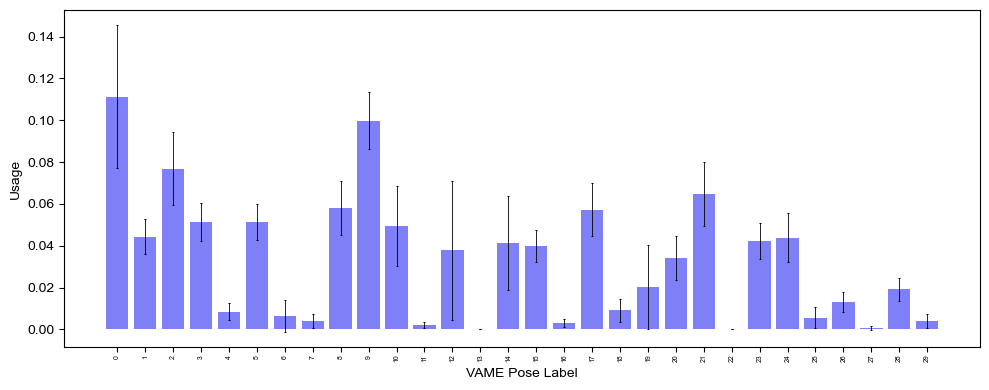

In [5]:
fig = plot.plot_module_usage(config,
                             module_usage,
                             style="bar_error",
                             figW=10,
                             figH=4)
if save:
    fig.savefig(save_path+"demo2-1_visualize-usage_no-subgroups.png",dpi=300)

## 2.2: Loading data and visualizing usage by subgroups
### 2.2a: Visualize usage of all modules across subgroups as bar/point plot
Now we may want to visualize data by subgroups. To do this, we have to specify the subgroups we would like to retrieve by specifying them by name (from the config) in our analyze.get_module_labels call, but all other details can be kept the same.

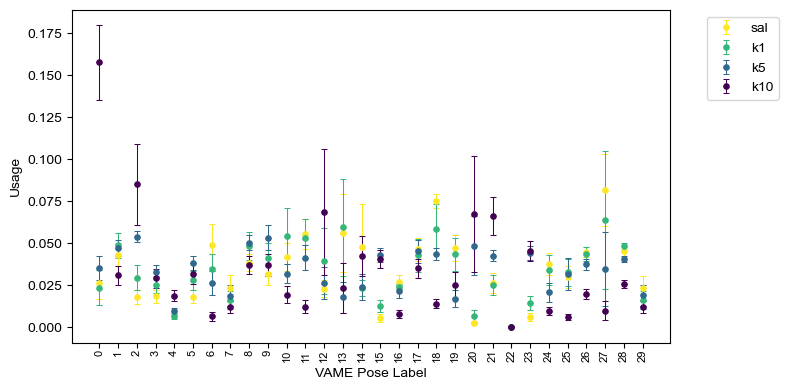

In [6]:
# get_module_labels with subgroups specified
labels_df = analyze.get_module_labels(config,0,1200,subgroups=["sal","k1","k5","k10"])

#Now, get_module_usage
module_usage = analyze.get_module_usage(config,labels_df)
fig = plot.plot_module_usage(config,
                             module_usage,
                             style="points",
                             figW=8,
                             figH=4,
                             cmap="viridis_r")
if save:
    fig.savefig(save_path+"demo2-2-a_visualize-usage_subgroups.png",dpi=300)

### 2.2b: Alternative subgroup usage plots: stacked and network
Perhaps we want a visualization that will more clearly point to overall differences between groups. Two alternative plots we can use for this are a stacked usage plot and a network plot, as shown below. Network plots only work for comparison between two subgroups.

Defaulting to using labels_df to get module_usage and module_transitions
Getting module usage


Getting module transitions


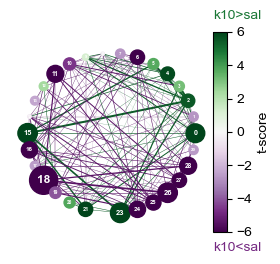

In [7]:
#Network plot
labels_df = analyze.get_module_labels(config,0,1200,subgroups=["sal","k10"])
fig = plot.network_plot(config, labels_df,cmap="PRGn")
if save:
    fig.savefig(save_path+"demo2-2-b_visualize-usage_subgroups-network.png",dpi=300)

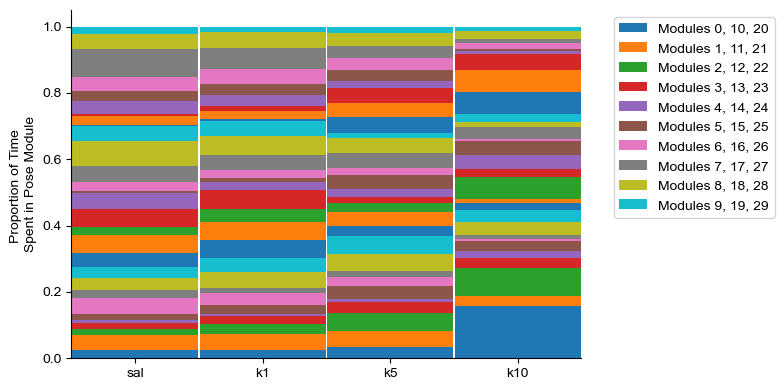

In [8]:
#Stacked usage plot
labels_df = analyze.get_module_labels(config,0,1200,subgroups=["sal","k1","k5","k10"])
module_usage = analyze.get_module_usage(config,labels_df)
fig = plot.plot_module_usage(config,
                             module_usage,
                             style="stacked",
                             figW=8,
                             figH=4)
if save:
    fig.savefig(save_path+"demo2-2-b_visualize-usage_subgroups-stacked.png",dpi=300)

### 2.2c: Visualize module usage over time in a single subgroup
Maybe our data involves some time-dependent manipulation (e.g., a drug or block design) and we want to see how this affects usage over time. For this, we can look at usage density in a single group over time in a "sandplot" (so called because it looks like colored sand layers in a decorative jar). For this, we need to include binsizes in the module usage object (with whatever temporal resolution we wish to plot - with padded convolution available).

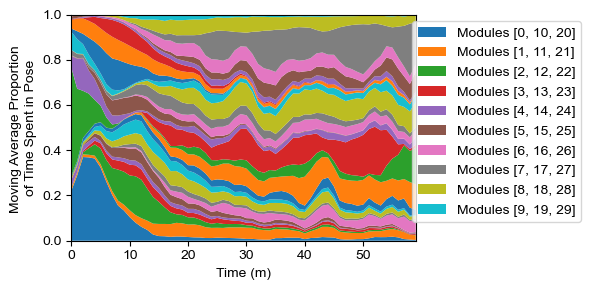

In [9]:
labels_df = analyze.get_module_labels(config,0,3600,subgroups=["k10"])
module_usage = analyze.get_module_usage(config,labels_df,binsize=60)
fig = plot.module_usage_sandplot(config, module_usage,convolve=30,long_legend=True)
if save:
    fig.savefig(save_path+"demo2-2-b_visualize-usage_subgroups-network.png",dpi=300)